In [1]:
import spacy
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import wikipedia
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\KIIT0001\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
nlp = spacy.load("en_core_web_sm")

topic = input("Enter Wikipedia topic: ")
wiki_page = wikipedia.page(topic)
text = wiki_page.content

text = re.sub(r'==.*?==+', '', text)
text = text.replace('\n', ' ')

In [4]:
# Extract entity pairs
def extract_entities(sentence):
    doc = nlp(sentence)
    subject = ""
    obj = ""
    for token in doc:
        if "subj" in token.dep_:
            subject = token.text
        if "obj" in token.dep_:
            obj = token.text
    return subject, obj

sentences = [sent.text for sent in nlp(text).sents]

data = []
for sentence in sentences:
    subj, obj = extract_entities(sentence)
    if subj and obj:
        data.append((subj, obj, sentence))

kg_df = pd.DataFrame(data, columns=["source", "target", "relation"])

In [5]:
# ------------------ CLEAN GRAPH ------------------

# Remove stopwords
kg_df = kg_df[~kg_df["source"].str.lower().isin(stop_words)]
kg_df = kg_df[~kg_df["target"].str.lower().isin(stop_words)]

# Remove duplicates & self loops
kg_df = kg_df.drop_duplicates()
kg_df = kg_df[kg_df["source"] != kg_df["target"]]

# ------------------ BUILD GRAPH ------------------

G = nx.from_pandas_edgelist(
    kg_df,
    "source",
    "target",
    create_using=nx.DiGraph()
)

# ------------------ GRAPH ANALYTICS ------------------

degree_centrality = nx.degree_centrality(G)
pagerank_scores = nx.pagerank(G)

# Get top 60 nodes by PageRank
top_nodes = sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:60]
important_set = set(node for node, _ in top_nodes)

# ------------------ EDGE-BASED FILTERING ------------------

edges_to_keep = []

for u, v in G.edges():
    if u in important_set or v in important_set:
        edges_to_keep.append((u, v))

G_filtered = nx.DiGraph()
G_filtered.add_edges_from(edges_to_keep)

# ------------------ PRINT ANALYTICS ------------------

print("\nTop 5 Entities by Degree Centrality:")
for node, score in sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(node, score)

print("\nTop 5 Entities by PageRank:")
for node, score in sorted(pagerank_scores.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(node, score)



Top 5 Entities by Degree Centrality:
paracetamol 0.16267942583732056
Paracetamol 0.10526315789473684
pain 0.043062200956937795
combination 0.03827751196172249
% 0.028708133971291863

Top 5 Entities by PageRank:
paracetamol 0.04459696449048542
liver 0.013047992443129411
osteoarthritis 0.012845741334998276
pain 0.01241662449117422
% 0.012306865093901151


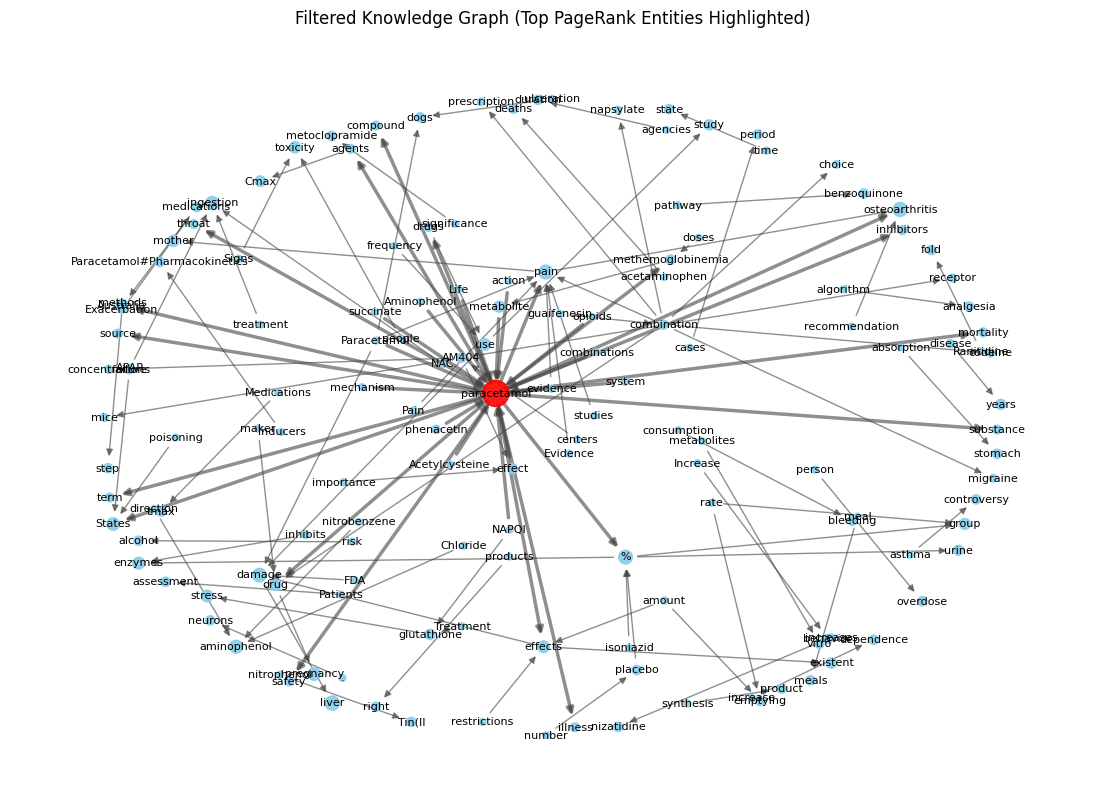

In [6]:
# ------------------ Visualization ------------------

plt.figure(figsize=(14, 10))

# Layout for filtered graph
pos = nx.spring_layout(G_filtered, k=1.2, iterations=200)

# Node sizes based on PageRank (better than degree here)
node_sizes = [pagerank_scores[node] * 8000 for node in G_filtered.nodes()]

# Highlight most important node
most_important = top_nodes[0][0]

node_colors = [
    "red" if node == most_important else "skyblue"
    for node in G_filtered.nodes()
]

# Draw nodes
nx.draw_networkx_nodes(
    G_filtered,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    alpha=0.9
)

edge_widths = []

for u, v in G_filtered.edges():
    if u == most_important or v == most_important:
        edge_widths.append(2.5)
    else:
        edge_widths.append(1)

nx.draw_networkx_edges(
    G_filtered,
    pos,
    edge_color="#444444",
    width=edge_widths,
    alpha=0.6
)

# Draw labels
nx.draw_networkx_labels(
    G_filtered,
    pos,
    font_size=8
)

plt.title("Filtered Knowledge Graph (Top PageRank Entities Highlighted)")
plt.axis("off")
plt.show()

In [16]:
def query_entity(G):
    if G.number_of_nodes() == 0:
        print("Graph is empty. No entities to query.")
        return

    print("\n--- Knowledge Graph Query Engine ---")
    print("Type an entity name to explore its connections.")
    print("Type 'list' to see some available entities.")
    print("Type 'exit' to quit.\n")

    # Create lowercase mapping for case-insensitive search
    node_map = {node.lower(): node for node in G.nodes()}

    while True:
        user_input = input("Enter entity: ").strip().lower()

        if user_input == "exit":
            print("Exiting query engine.")
            break

        if user_input == "list":
            print("\nSample Available Entities:")
            for node in list(G.nodes())[:20]:
                print("-", node)
            print()
            continue

        if user_input in node_map:
            actual_node = node_map[user_input]

            print(f"\nConnections for '{actual_node}':\n")

            # Outgoing edges
            outgoing = list(G.successors(actual_node))
            incoming = list(G.predecessors(actual_node))

            if outgoing:
                print("→ Outgoing Relations:")
                for neighbor in outgoing:
                    print("   ", actual_node, "→", neighbor)
            else:
                print("→ No outgoing relations.")

            if incoming:
                print("\n← Incoming Relations:")
                for neighbor in incoming:
                    print("   ", neighbor, "→", actual_node)
            else:
                print("\n← No incoming relations.")

            print()

        else:
            print("Entity not found. Type 'list' to see available entities.\n")
query_entity(G)


--- Knowledge Graph Query Engine ---
Type an entity name to explore its connections.
Type 'list' to see some available entities.
Type 'exit' to quit.

Entity not found. Type 'list' to see available entities.


Connections for 'fever':

→ No outgoing relations.

← Incoming Relations:
    Paracetamol → fever
    efficacy → fever
    who → fever


Connections for 'ADHD':

→ No outgoing relations.

← Incoming Relations:
    studies → ADHD


Connections for 'Medicines':

→ No outgoing relations.

← Incoming Relations:
    It → Medicines

Exiting query engine.
